In [86]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px 
import warnings
import plotly.io as pio

pio.templates.default = "plotly_white" 
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('../data/AIML Dataset.csv')
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4731021,332,PAYMENT,26953.36,C431066659,20209.07,0.00,M75471010,0.00,0.00,0,0
3309089,252,PAYMENT,14265.42,C649101751,0.00,0.00,M142875152,0.00,0.00,0,0
3512956,259,CASH_OUT,176499.60,C565084712,0.00,0.00,C4582912,1544440.13,1720939.73,0,0
863361,42,PAYMENT,8058.48,C949202676,57635.00,49576.52,M907921569,0.00,0.00,0,0
5881579,403,CASH_OUT,34132.77,C1684581584,0.00,0.00,C842785911,498605.00,794696.54,0,0


In [11]:
# ----------------------------
# INFORMACIÓN DE LA ESTRUCTURA DEL DATASET
# ----------------------------
print('Columnas: ', list(df.columns))
print('Nº de Filas: ', df.shape[0])
print('Nº de columnas: ', df.shape[1])


Columnas:  ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Nº de Filas:  6362620
Nº de columnas:  11


In [12]:
# -----------------------
# INFORMACIÓN SOBRE EL DATASET
# -----------------------
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [13]:
print('---------------')
print('AVERIGUAR CUANTAS TRANSACIONES SON FRAUDE')
print('---------------')
print(df['isFraud'].value_counts())

print('---------------')
print('AVERIGUAR CUANTAS TRANSACIONES SON *MARCADAS* COMO FRAUDE')
print('---------------')
print(df['isFlaggedFraud'].value_counts())

---------------
AVERIGUAR CUANTAS TRANSACIONES SON FRAUDE
---------------
isFraud
0    6354407
1       8213
Name: count, dtype: int64
---------------
AVERIGUAR CUANTAS TRANSACIONES SON *MARCADAS* COMO FRAUDE
---------------
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [14]:
# ---------------
# AVERIGUAR SI TENEMOS VALORES NULOS EN NUESTRO DATASET')
# ---------------
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [15]:
#---------------
# AVERIGUAR EL PORCENTAJE DE TRANSACIONES FRAUDALENTAS
#---------------

print('% de Transacciones Fraudulentas: ', round((df['isFraud'].value_counts()[1] / df.shape[0])*100, 2))

% de Transacciones Fraudulentas:  0.13


In [ ]:
#---------------
# HISTOGRAMA DE LOS TIPOS DE TRANSACCIONES EN EL DATASET
#---------------

fig = px.histogram(
    df['type'].value_counts().reset_index(),
    x = 'type',
    y = 'count',
    color = 'type',
    opacity = 0.8,
    

)

fig.update_layout(
    title=dict(text="Histograma De Los Tipos De Transacciones"),
    xaxis=dict(title=dict(text="Tipos")),
    yaxis=dict(title=dict(text="Cuenta")),
    legend=dict(title=dict(text="Tipos")),
)

fig.show()

fig.write_image("../images/tipos_de_transacciones.png")

In [40]:
#---------------
# VER LA DISTRIBICIÓN DE TRANSACCIONES FRAUDULENTAS SEGÚN EL TIPO DE TRANSACCIÓN
#---------------
df_types_fraud = (
    df.groupby('type')['isFraud']
    .agg('sum')
    .sort_values(ascending=False)
    .reset_index()
)

df_types_fraud

,type,isFraud
0,CASH_OUT,4116
1,TRANSFER,4097
2,CASH_IN,0
3,DEBIT,0
4,PAYMENT,0


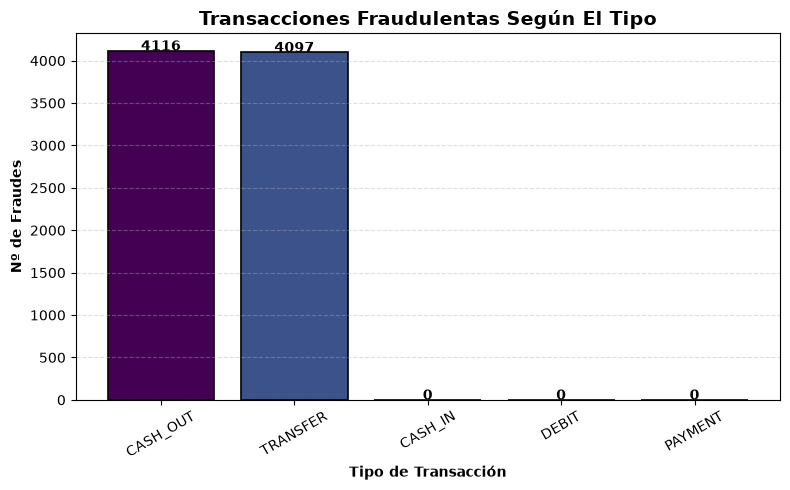

In [62]:
#---------------
# BAR CHART REPRESENTANDO FRAUDES SEGÚN EL TIPO DE TRANSACCIÓN
#---------------
colors = plt.cm.viridis(np.linspace(0, 1, len(df_types_fraud)))

plt.figure(figsize=(8,5))
bars = plt.bar(
    df_types_fraud['type'], 
    df_types_fraud['isFraud'], 
    color = colors,
    edgecolor="black",
    linewidth=1.2)

plt.title("Transacciones Fraudulentas Según El Tipo", fontsize=14, fontweight="bold")
plt.xlabel("Tipo de Transacción", fontsize=10, fontweight="bold")
plt.ylabel("Nº de Fraudes", fontsize=10, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30)

# Añadir valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        int(height),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [48]:
#---------------
# ESTADISTICAS DEL DATASET
#---------------

df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

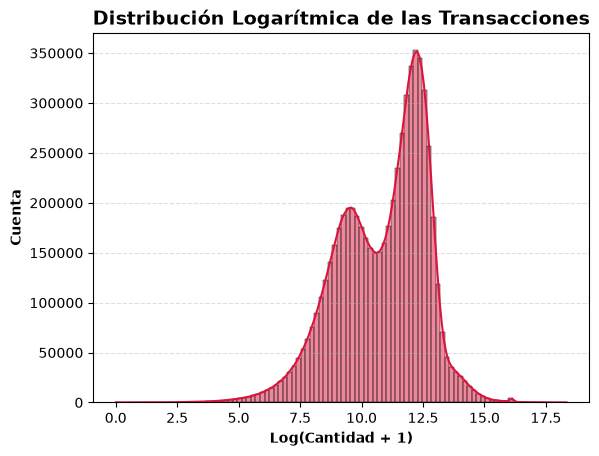

In [52]:
#---------------
# VISUALIZACIÓN DE LAS ESTADISTICAS
#---------------

sns.histplot(np.log1p(df['amount']), color= 'crimson', kde= True, bins=100)
plt.title("Distribución Logarítmica de las Transacciones", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xlabel("Log(Cantidad + 1)", fontsize=10, fontweight="bold")
plt.ylabel("Cuenta", fontsize=10, fontweight="bold")
plt.show()



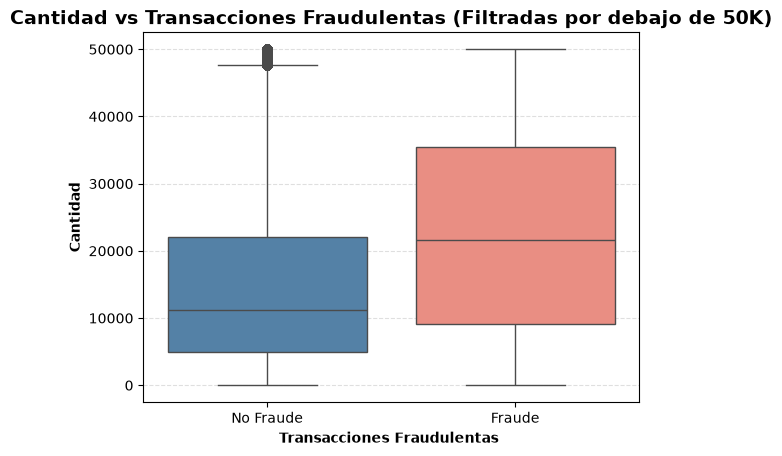

In [63]:
#---------------
# BOXPLOT: CANTIDAD VS TRANSACCIONES FRAUDULENTAS
#---------------

colors_fraud = ["steelblue", "salmon"]

sns.boxplot(
    data = df[df['amount'] < 50000],
    x = 'isFraud',
    y = 'amount', 
    palette = colors_fraud
)
plt.title("Cantidad vs Transacciones Fraudulentas (Filtradas por debajo de 50K)", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xlabel("Transacciones Fraudulentas ", fontsize=10, fontweight="bold")
plt.ylabel("Cantidad", fontsize=10, fontweight="bold")
plt.xticks([0,1], ["No Fraude", "Fraude"])
plt.show()


In [ ]:
#---------------
# ENTENDER LA DIFERENCIA DE BALANCES - ORIGINAL Y DESTINO
#---------------

df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

print("Sumatoria de Diferencia de Balance en la Cuenta Original: ", (df['balanceDiffOrig']< 0).sum())
print('------------------------------')
print("Sumatoria de Diferencia de Balance en la Cuenta Destinataria: ", (df['balanceDiffDest']< 0).sum())


Sumatoria de Diferencia de Balance en la Cuenta Original:  1399253
------------------------------
Sumatoria de Diferencia de Balance en la Cuenta Destinataria:  1238864


In [ ]:
#---------------
# VISUALIZAR LAS TRANSACCIONES FRAUDULENTAS POR STEP (DIAS)
#---------------

df_frauds_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()

fig = px.line(
    x=df_frauds_step.index,
    y=df_frauds_step.values,
    title="Evolución temporal de transacciones fraudulentas",
    labels={
        "x": "Tiempo (step)",
        "y": "Número de fraudes"
    }
)

fig.update_traces(
    line=dict(color="darkorange", width=2)
)

fig.update_layout(
    title=dict(font=dict(size=18)),
    xaxis=dict(title_font=dict(size=12, family="Arial", color="black")),
    yaxis=dict(title_font=dict(size=12, family="Arial", color="black")),
)

fig.show()

fig.write_image("../images/evol_temporal_fraude.png")

In [71]:
# No hace falta la columna step
df.drop(columns = 'step', inplace=True)

In [ ]:
#---------------
# ENTENDER LOS CLIENTES QUE HACEN LAS MAYORES TRANSACCIONES - TOP RECEPTORES Y TOP MENSAJEROS
#---------------

top_mensajeros = df['nameOrig'].value_counts().sort_values(ascending = False).head(10)
top_mensajeros

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [ ]:
top_receptores = df['nameDest'].value_counts().sort_values(ascending = False).head(10)
top_receptores

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [77]:
fraud_by_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().sort_values(ascending = False).head(10)
fraud_by_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [80]:
#---------------
# ANALIZAR LA DISTRIBUCIÓN DE FRAUDE EN CASH OUT Y TRANSFER
#---------------

df_fraud_type = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

print(df_fraud_type['type'].value_counts())

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64


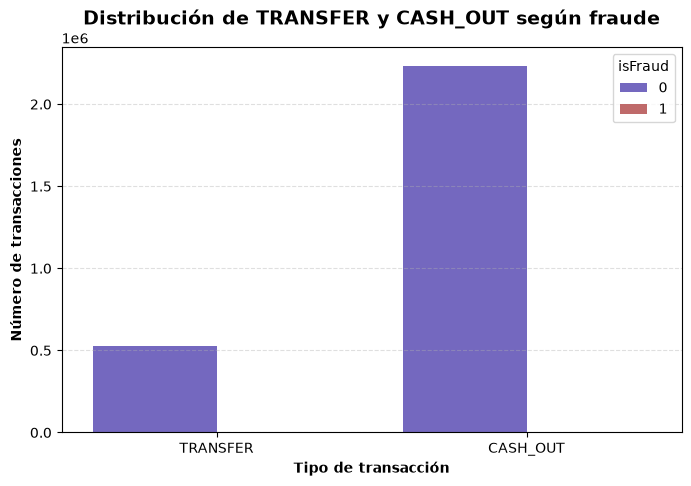

In [84]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_fraud_type,
    x="type",
    hue="isFraud",
    palette=["slateblue", "indianred"]
)

plt.title("Distribución de TRANSFER y CASH_OUT según fraude",
          fontsize=14, fontweight="bold")

plt.xlabel("Tipo de transacción", fontsize=10, fontweight="bold")
plt.ylabel("Número de transacciones", fontsize=10, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [91]:
#---------------
# HEATMAP PARA MEDIR LAS CORRELACIONES ENTRE LAS VARIABLES
#---------------

cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud"
]

corr = df[cols].corr()

fig = px.imshow(
    corr,
    text_auto=".3f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Matriz de correlación de variables financieras"
)

fig.update_layout(title_x=0.5,  width=800, height=700)
fig.show()

fig.write_image("../images/heatmap_var_financieras.png")



In [ ]:
#---------------
# ANALIZAR CUENTAS SOSPECHOSAS - AQUELLAS QUE QUEDAN A 0 DESPUÉS DE TRANFERENCIA
#---------------

cero_despues_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]

print('Nº De Transacciones Sospechosas: ', len(cero_despues_transfer))

Nº De Transacciones Sospechosas:  1188074
